In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings; warnings.filterwarnings('ignore')

# Load dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00320/student.zip"
import urllib.request, zipfile, io

response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.read()))
zip_file.extractall("/content/student_data")

df = pd.read_csv("/content/student_data/student-mat.csv", sep=';')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (395, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


Pass rate: 0.67


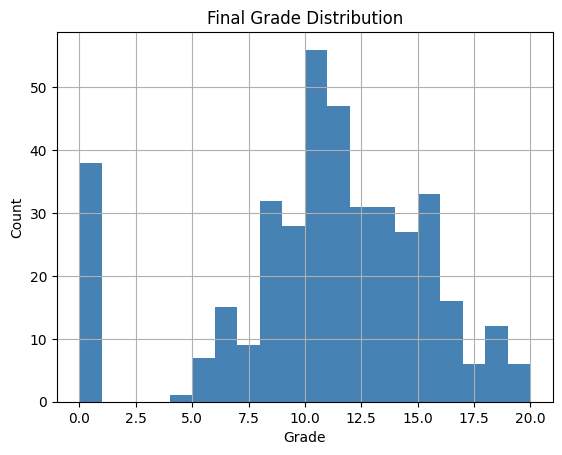

In [19]:
df['pass'] = (df['G3'] >= 10).astype(int)
print("Pass rate:", df['pass'].mean().round(2))
df['G3'].hist(bins=20, color='steelblue')
plt.title('Final Grade Distribution')
plt.xlabel('Grade'); plt.ylabel('Count')
plt.show()

In [20]:
df_enc = pd.get_dummies(df.drop('G3', axis=1))
X = df_enc.drop('pass', axis=1)
y = df_enc['pass']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest accuracy:", round(accuracy_score(y_test, rf.predict(X_test)), 3))

Random Forest accuracy: 0.911


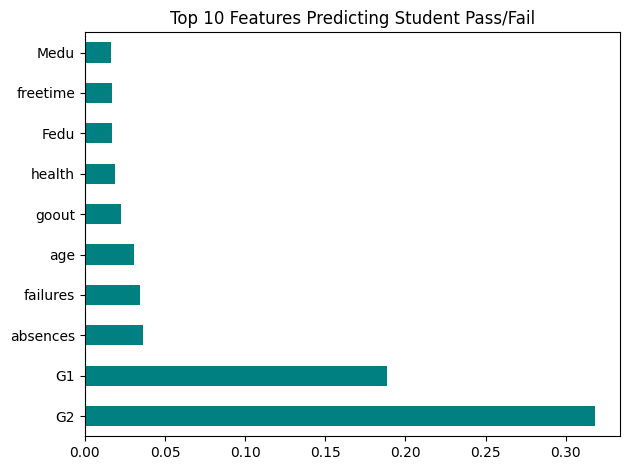

In [21]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Features Predicting Student Pass/Fail')
plt.tight_layout(); plt.show()